# Plot supplementary material

In [1]:
import ROOT
import os,sys,json
import argparse
from datetime import date    
import numpy as np
import copy
import math
import mplhep as hep
import matplotlib.pyplot as plt
from utils import *
ROOT.gROOT.SetBatch(1)
hep.style.use("CMS")

Welcome to JupyROOT 6.24/07


## Material veto

/cvmfs/cms.cern.ch/el8_amd64_gcc10/external/py3-numpy/1.22.4-62e28bace1c65ef46c4a0988f2d65108/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el8_amd64_gcc10/external/py3-numpy/1.22.4-62e28bace1c65ef46c4a0988f2d65108/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


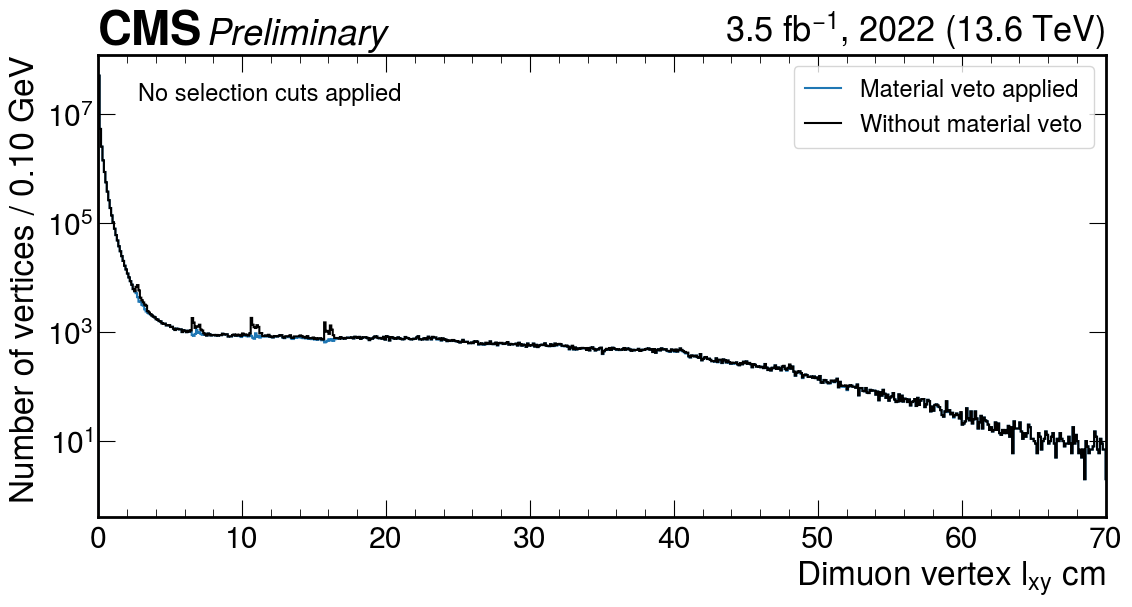

In [2]:
fn_nv = '/ceph/cms/store/user/fernance/EXO-24-016/MaterialVeto/NoVeto/histograms_Data_2022_all.root'
fn_wv = '/ceph/cms/store/user/fernance/EXO-24-016/MaterialVeto/WithVeto/histograms_Data_2022_all.root'

f_nv = ROOT.TFile(fn_nv)
f_wv = ROOT.TFile(fn_wv)

h_nv = f_nv.Get('hsvselass_lxy')
h_wv = f_wv.Get('hsvselass_lxy')

h_nv.Rebin(1)
h_wv.Rebin(1)

wv, bwv = getValues(h_wv)
nv, bnv = getValues(h_nv)

fig, ax = plt.subplots(1, 1, figsize=(13, 6.))
hep.cms.label("Preliminary", data=True, year='2022', lumi = 3.5, com='13.6', ax=ax)

hep.histplot(wv, bwv, color='tab:blue', label = 'Material veto applied', histtype="step", ax=ax)
hep.histplot(nv, bnv, color='k', label = 'Without material veto', histtype="step", ax=ax)

ax.set_ylabel('Number of vertices / %.2f GeV'%(bwv[1] - bwv[0]), fontsize=24)
ax.set_xlabel(r'Dimuon vertex $l_{xy}$ cm', fontsize=24)

ax.set_yscale('log')
ax.set_xlim(0, 70)

ax.text(0.04, 0.94, 'No selection cuts applied', fontsize=17, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)

ax.legend(loc="upper right", fontsize=17, frameon=True)
fig.savefig("materialVeto_paper.png", dpi=140) 

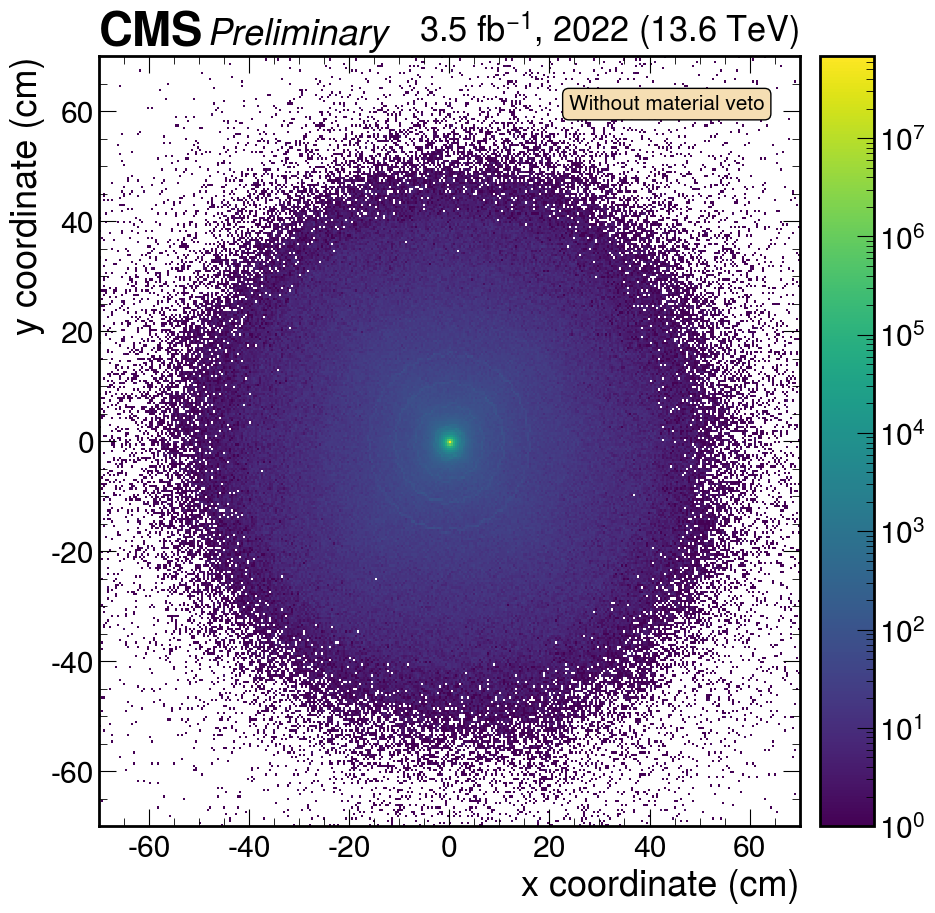

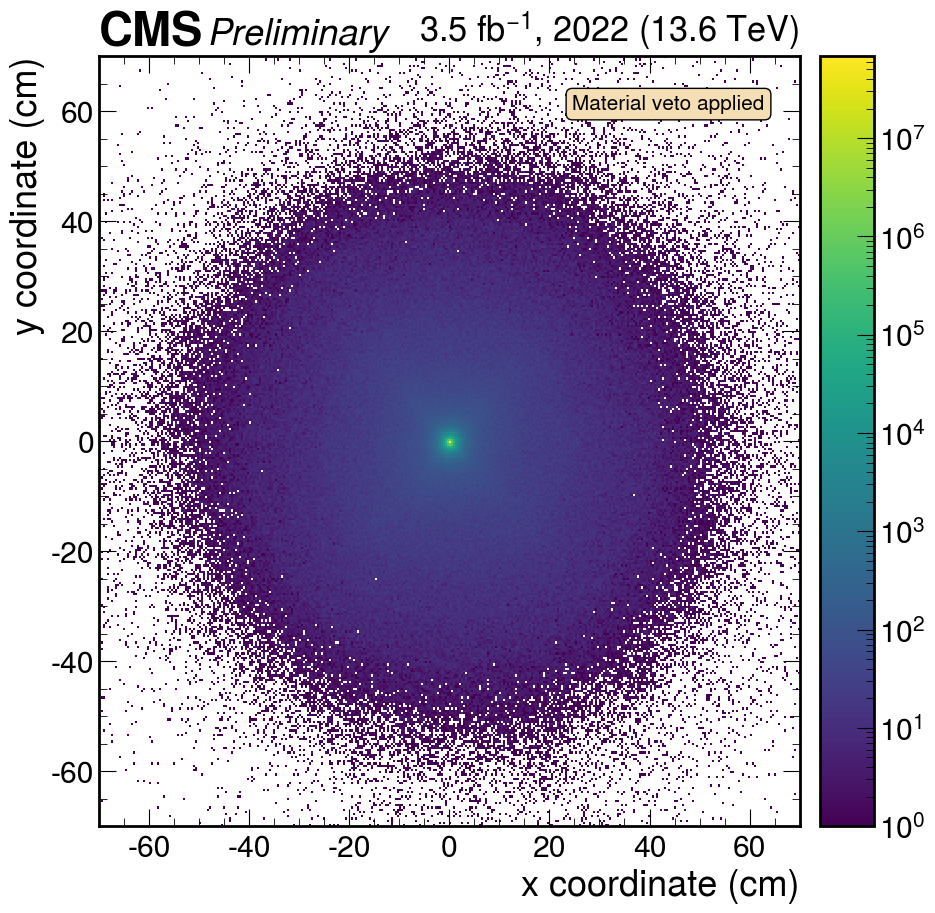

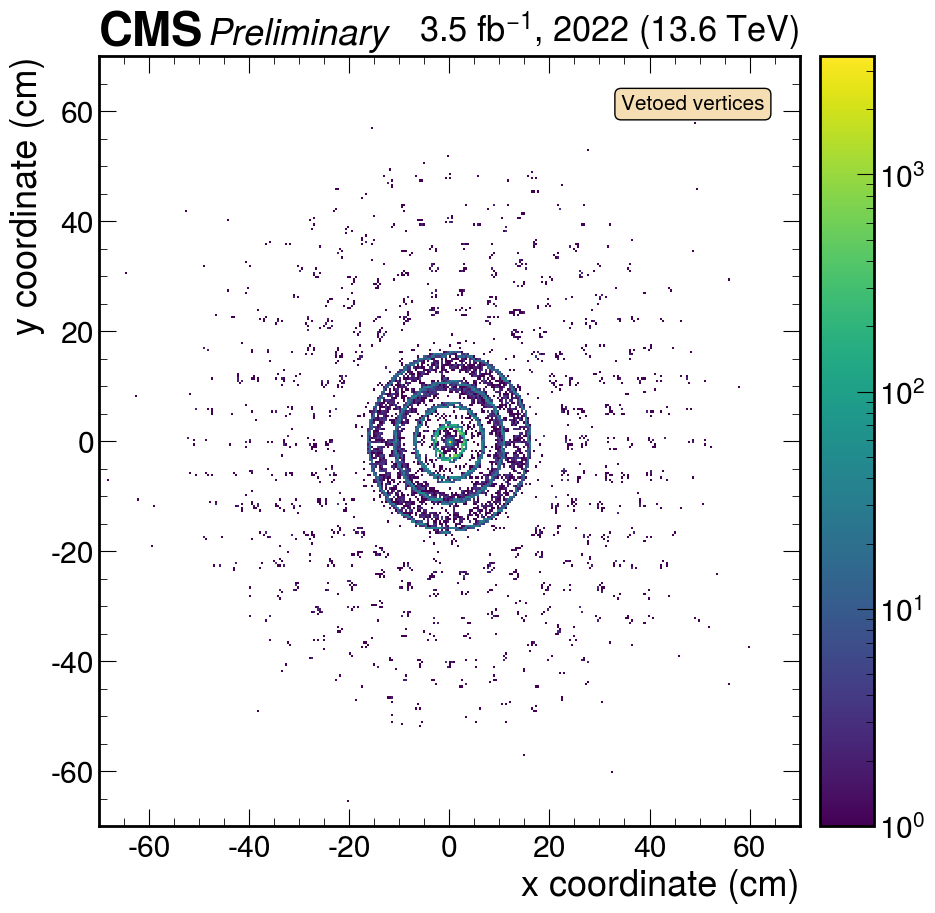

In [3]:
import matplotlib.colors as colors

fn_nv = '/ceph/cms/store/user/fernance/EXO-24-016/MaterialVeto/NoVeto/histograms_Data_2022_all.root'
fn_wv = '/ceph/cms/store/user/fernance/EXO-24-016/MaterialVeto/WithVeto/histograms_Data_2022_all.root'

f_nv = ROOT.TFile(fn_nv)
f_wv = ROOT.TFile(fn_wv)

h2_nv = f_nv.Get('hsvsel_yvsx')
h2_wv = f_wv.Get('hsvsel_yvsx')

h2_nv.RebinX(4)
h2_nv.RebinY(4)

h2_wv.RebinX(4)
h2_wv.RebinY(4)

v_nv, x_nv, y_nv = getValues2D(h2_nv)
v_wv, x_wv, y_wv = getValues2D(h2_wv)

## Without veto
fig, ax = plt.subplots(figsize=(10, 10))
hep.cms.label("Preliminary", data=True, year='2022', lumi = 3.5, com='13.6', ax=ax)
pcm = hep.hist2dplot(v_nv, x_nv, y_nv, ax=ax, norm=colors.LogNorm())
ax.set_xlabel("x coordinate (cm)")
ax.set_ylabel("y coordinate (cm)")
ax.set_xlim(-70, 70)
ax.set_ylim(-70, 70)
props = dict(boxstyle='round', facecolor='wheat', alpha=1.0)
ax.text(0.95, 0.95, 'Without material veto', transform=ax.transAxes, fontsize=15, verticalalignment='top',horizontalalignment='right', bbox=props)
fig.savefig("materialmap_noveto_paper.png", dpi=140) 

# With veto
fig, ax = plt.subplots(figsize=(10, 10))
hep.cms.label("Preliminary", data=True, year='2022', lumi = 3.5, com='13.6', ax=ax)
pcm = hep.hist2dplot(v_wv, x_wv, y_wv, ax=ax, norm=colors.LogNorm())
ax.set_xlabel("x coordinate (cm)")
ax.set_ylabel("y coordinate (cm)")
ax.set_xlim(-70, 70)
ax.set_ylim(-70, 70)
props = dict(boxstyle='round', facecolor='wheat', alpha=1.0)
ax.text(0.95, 0.95, 'Material veto applied', transform=ax.transAxes, fontsize=15, verticalalignment='top',horizontalalignment='right', bbox=props)
fig.savefig("materialmap_withveto_paper.png", dpi=140)

# Vetos
v_veto = v_nv - v_wv
fig, ax = plt.subplots(figsize=(10, 10))
hep.cms.label("Preliminary", data=True, year='2022', lumi = 3.5, com='13.6', ax=ax)
pcm = hep.hist2dplot(v_veto, x_wv, y_wv, ax=ax, norm=colors.LogNorm())
ax.set_xlabel("x coordinate (cm)")
ax.set_ylabel("y coordinate (cm)")
ax.set_xlim(-70, 70)
ax.set_ylim(-70, 70)
props = dict(boxstyle='round', facecolor='wheat', alpha=1.0)
ax.text(0.95, 0.95, 'Vetoed vertices', transform=ax.transAxes, fontsize=15, verticalalignment='top',horizontalalignment='right', bbox=props)
fig.savefig("materialmap_vetos_paper.png", dpi=140)




## Selection plots during ARC review

To address efficiency questions from the ARC and have comparisons with EXO-20-014

### Isolation and number of excess hits vs Run 2

Comparing same ranges wrt to EXO-20-014

In [4]:
period = '2022'
inDir = []

# For isolation
#baseDir = '/ceph/cms/store/user/fernance/EXO-24-016/vsRun2Comp_allCuts_2022_forIsolation/'
#inDir = []
#inDir.append('lxy-0p0To0p2/')
#inDir.append('lxy-0p2To1p0/')
#inDir.append('lxy-1p0To11p0/')

# For excess hits cut
baseDir = '/ceph/cms/store/user/fernance/EXO-24-016/vsRun2Comp_allCuts_2022_forHitSelection/'
inDir = []
inDir.append('lxy-3p1To7p0/')
inDir.append('lxy-1p0To11p0/')

samples = []
samples.append('Data-lowMass')
samples.append('Data-highMass')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-100.00mm')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-8p0_ctau-10.00mm')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1.00mm')
samples.append('Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm')
samples.append('Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm')


legnames = {}
legnames['Data-lowMass'] = r'Data (mass $<$ 5 GeV)'
legnames['Data-highMass'] = r'Data (mass $>$ 5 GeV)'
legnames['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-100.00mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 2 GeV, $c\tau_{{Z_{{D}}}} =$ 100 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-8p0_ctau-10.00mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 8 GeV, $c\tau_{{Z_{{D}}}} =$ 10 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1.00mm'] = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 14 GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"
legnames['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm'] = r"ScenarioA: $m_\pi = 5$ GeV, $m_A = 2.4$ GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"
legnames['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm'] = r"ScenarioB1: $m_\pi = 4$ GeV, $m_A = 1.33$ GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"

colors = {}
colors['Data-lowMass'] = 'k'
colors['Data-highMass'] = 'b'
colors['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-100.00mm'] = 'tab:purple'
colors['Signal_HTo2ZdTo2mu2x_MZd-8p0_ctau-10.00mm'] =  'tab:red'
colors['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1.00mm'] =  'tab:brown'
colors['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm'] =  'tab:blue'
colors['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm'] =  'tab:green'

#colors[] = 
#colors[] = 

Data-lowMass 0.8213250055766228
Data-highMass 0.7268370607028753
Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-100.00mm 0.9861689220116715
Signal_HTo2ZdTo2mu2x_MZd-8p0_ctau-10.00mm 0.9835011529653437
Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1.00mm 0.9735247152562905
Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm 0.9714921888074495
Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm 0.9695932691680674
Data-lowMass 0.9912428935782169
Data-highMass 0.765209553853087
Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-100.00mm 0.9850339935810939
Signal_HTo2ZdTo2mu2x_MZd-8p0_ctau-10.00mm 0.9830549745020112
Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1.00mm 0.9982629026046815
Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm 0.9930573817678161
Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm 0.9939666928079278


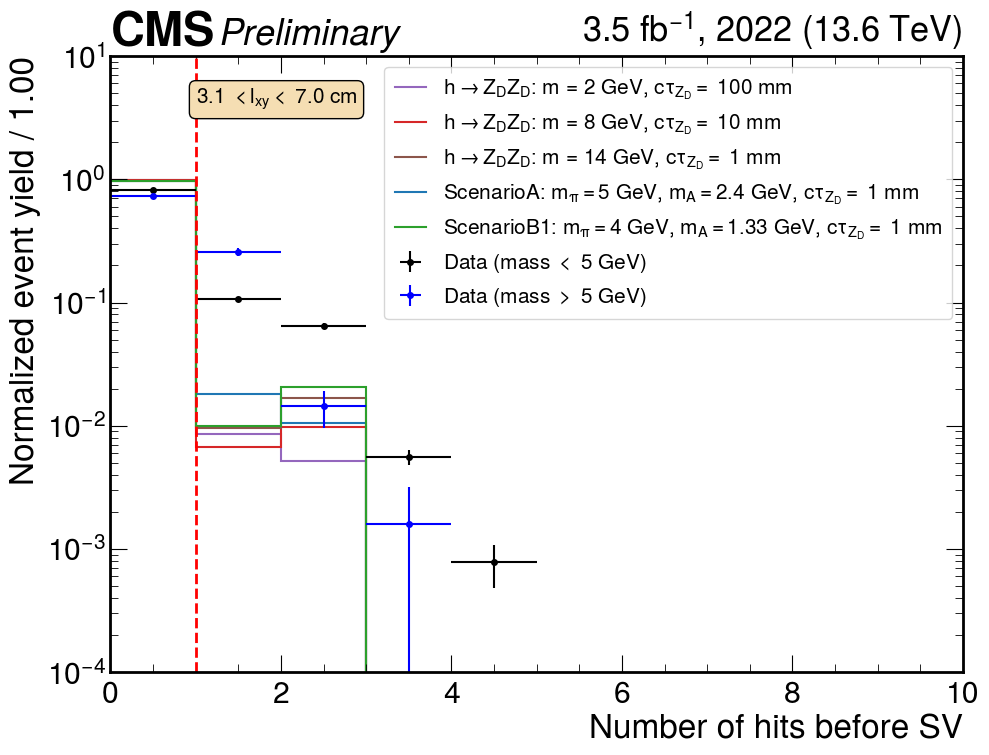

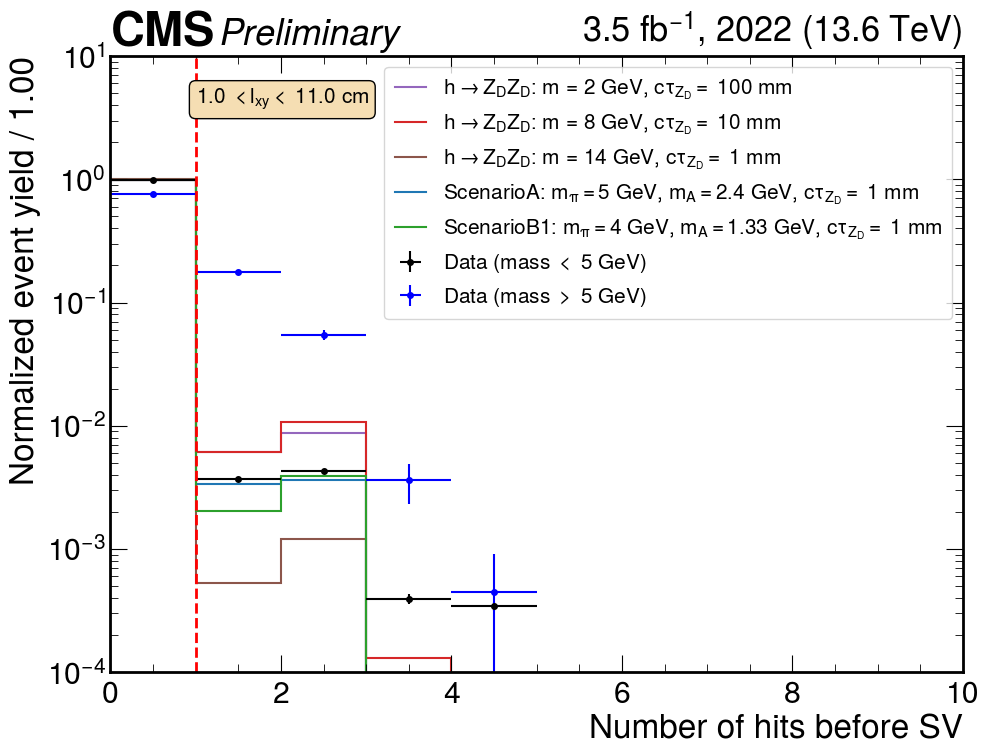

In [5]:
# Fill histograms:
hnn = []
# For isolation
#hnn.append(['hselmuon_pfreliso0p3all', r'Muon relative PF isolation ($\Delta R < 0.3$)', 0.2])
hnn.append(['hdimuon_hitsbeforesv', r'Number of hits before SV', 1])
# For excess cut

for dirpath in inDir:
    for hn in hnn:
        # Load histograms
        histograms = {}
        for sample in samples:
            tfile = ROOT.TFile('%s/histograms_%s_%s_all.root'%(baseDir + dirpath, sample, period))
            th1f = tfile.Get(hn[0])
            histograms[sample] = copy.deepcopy(th1f.Clone("%s_%s"%(hn,sample)))
            #histograms[sample].Scale(1./histograms[sample].Integral())
    
        # Plot histograms:
        fig, ax = plt.subplots(1, 1, figsize=(11, 8))
        hep.cms.label("Preliminary", data=True, year='2022', lumi = 3.5, com='13.6', ax=ax)
        ax.set_yscale("log")
        ax.set_xlabel(hn[1], fontsize=24)
        for sample in samples:
            dhist, dedges = getValues(histograms[sample])
            y_err = (dhist**0.5)
            dhist = dhist/histograms[sample].Integral()
            y_err = y_err/histograms[sample].Integral()
            ddedges = []
            if 'Data' in sample:
                for v in range(0, len(dedges)-1):
                    ddedges.append(dedges[v] + 0.5*(dedges[v+1] - dedges[v]))
                ax.errorbar(np.array(ddedges), dhist, yerr=y_err, xerr=0.5*(dedges[1] - dedges[0]), fmt='o', label=legnames[sample], color=colors[sample], markersize=4)
            else:
                hep.histplot(dhist, dedges, color=colors[sample], label = legnames[sample], histtype="step", ax=ax)
            ## Dummy for efficiency:
            eff = 0.0
            for i in range(1): eff += dhist[i] # 4 for isolation : 1 for hits
            print(sample, eff)
        #
        # Box for the lxy label
        if 'lxy' in dirpath:
            lxymin = float(dirpath.split('To')[0][4:].replace('p', '.'))
            lxymax = float(dirpath.split('To')[1][:-1].replace('p', '.'))
            props = dict(boxstyle='round', facecolor='wheat', alpha=1.0)
            ax.text(0.1, 0.95, r'%.1f $< l_{xy} <$ %.1f cm'%(lxymin, lxymax), transform=ax.transAxes, fontsize=15, verticalalignment='top', bbox=props)
        # Additional handling of the axis
        ax.set_ylabel('Normalized event yield / %.2f GeV'%(dedges[1] - dedges[0]), fontsize=24)
        ax.set_ylim(1e-4, 10.0) # up 1.0
        if 'rel' in hn[0] or 'hit' in hn[0]:
            ax.set_ylabel('Normalized event yield / %.2f'%(dedges[1] - dedges[0]), fontsize=24)
        if 'rel' in hn[0]:
            ax.set_xlim(0.0, 1.0)
        else:
            ax.set_xlim(0.0, 10.0)
        # Legend
        ax.legend(loc="upper right", fontsize=15, frameon=True)
        # Cut line
        ax.axvline(x=hn[2], linestyle='--', color='red', linewidth=2)
        # Save
        fig.savefig("%s_paper_%s.png"%(hn[0], dirpath[:-1]), dpi=140) 

### PU veto vs Run 2


In [6]:
def plotSupplementaryHistograms(hist, samples, legnames, colors, period, ylog = False, text=False):
    dirpath = hist[0]
    hname = hist[1]
    xlabel = hist[2]
    ylog = hist[3]
    xcut = hist[4]
    rbn = hist[5]
    unit = hist[6]

    # Load histograms
    histograms = {}
    for sample in samples:
        tfile = ROOT.TFile('%s/histograms_%s_%s_all.root'%(dirpath, sample, period))
        th1f = tfile.Get(hname)
        th1f.Rebin(rbn)
        histograms[sample] = copy.deepcopy(th1f.Clone("%s_%s"%(hname,sample)))
    
    # Plot histograms:
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    if 'Years' in period:
        hep.cms.label("Supplementary", data=True, lumi = 6.2, com='13.6', ax=ax)
    else:
        hep.cms.label("Supplementary", data=True, year=period, com='13.6', ax=ax)
    if ylog:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel, fontsize=24)
    for sample in samples:
        dhist, dedges = getValues(histograms[sample], overflow=True)
        y_err = (dhist**0.5)
        dhist = dhist/histograms[sample].Integral()
        y_err = y_err/histograms[sample].Integral()
        ddedges = []
        if 'Data' in sample:
            if ylog:
                ax.set_ylim(0.1, 100*max(dhist))
            else:
                ax.set_ylim(0.0, 1.3*max(dhist))
            for v in range(0, len(dedges)-1):
                ddedges.append(dedges[v] + 0.5*(dedges[v+1] - dedges[v]))
            ax.errorbar(np.array(ddedges), dhist, yerr=y_err, xerr=0.5*(dedges[1] - dedges[0]), fmt='o', label=legnames[sample], color=colors[sample], markersize=4)
        else:
            hep.histplot(dhist, dedges, color=colors[sample], label = legnames[sample], histtype="step", ax=ax)
    #
    ax.set_xlim(dedges[0], dedges[-1])
    #
    # Box for text
    if text:
        props = dict(boxstyle='round', facecolor='wheat', alpha=1.0)
        ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=15, verticalalignment='top', bbox=props)
    # Additional handling of the axis
    ax.set_ylabel('Normalized event yield / %.2f %s'%(dedges[1] - dedges[0], unit), fontsize=24)
    # Legend
    ax.legend(loc="upper right", fontsize=15, frameon=True)
    # Cut line
    ax.axvline(x=xcut, linestyle='--', color='red', linewidth=2)
    # Save
    fig.savefig("%s_paper_%s.png"%(hname, str(period)), dpi=140) 

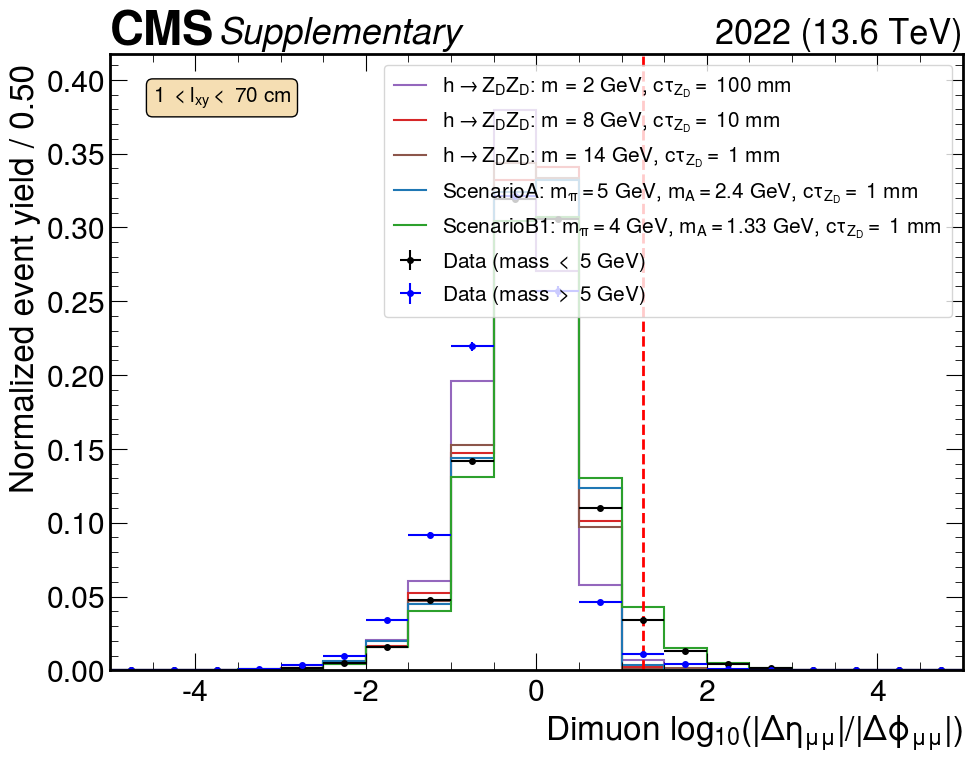

In [7]:
period = '2022'
#
cephpath = '/ceph/cms/store/user/fernance/EXO-24-016/'
#
samples = []
samples.append('Data-lowMass')
samples.append('Data-highMass')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-100.00mm')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-8p0_ctau-10.00mm')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1.00mm')
samples.append('Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm')
samples.append('Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm')
#
hist_list = [] # dirpath, hname, lxy range, x-label, y-log, , rebin
hist_list.append([cephpath + 'supplementary_noDimuonAngularSel_2022/lxy-1p0To70p0/',
                  'hdimuon_detadphiratio',
                  r'Dimuon log$_{10}(|\Delta\eta_{\mu\mu}|/|\Delta\phi_{\mu\mu}|)$',
                  False,
                  1.25,
                  5,
                  ''])
#
legnames = {}
legnames['Data-lowMass'] = r'Data (mass $<$ 5 GeV)'
legnames['Data-highMass'] = r'Data (mass $>$ 5 GeV)'
legnames['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-100.00mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 2 GeV, $c\tau_{{Z_{{D}}}} =$ 100 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-8p0_ctau-10.00mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 8 GeV, $c\tau_{{Z_{{D}}}} =$ 10 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1.00mm'] = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 14 GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"
legnames['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm'] = r"ScenarioA: $m_\pi = 5$ GeV, $m_A = 2.4$ GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"
legnames['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm'] = r"ScenarioB1: $m_\pi = 4$ GeV, $m_A = 1.33$ GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"
#
colors = {}
colors['Data-lowMass'] = 'k'
colors['Data-highMass'] = 'b'
colors['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-100.00mm'] = 'tab:purple'
colors['Signal_HTo2ZdTo2mu2x_MZd-8p0_ctau-10.00mm'] =  'tab:red'
colors['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1.00mm'] =  'tab:brown'
colors['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm'] =  'tab:blue'
colors['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm'] =  'tab:green'
#

for hist in hist_list:
    plotSupplementaryHistograms(hist, samples, legnames, colors, period, False, r'1 $< l_{xy} <$ 70 cm')

## Supplementary material: Selection plots

Update of the plots for supplementary material during ARC review

### Prompt muon veto

Cuts applied on the muons for the prompt muon veto

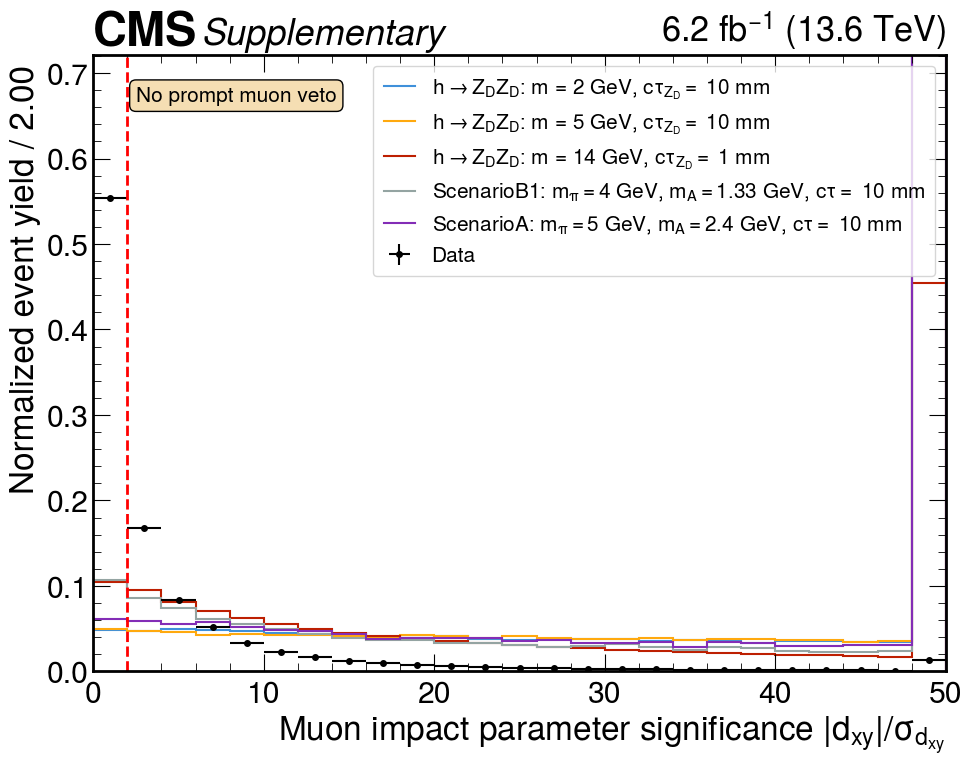

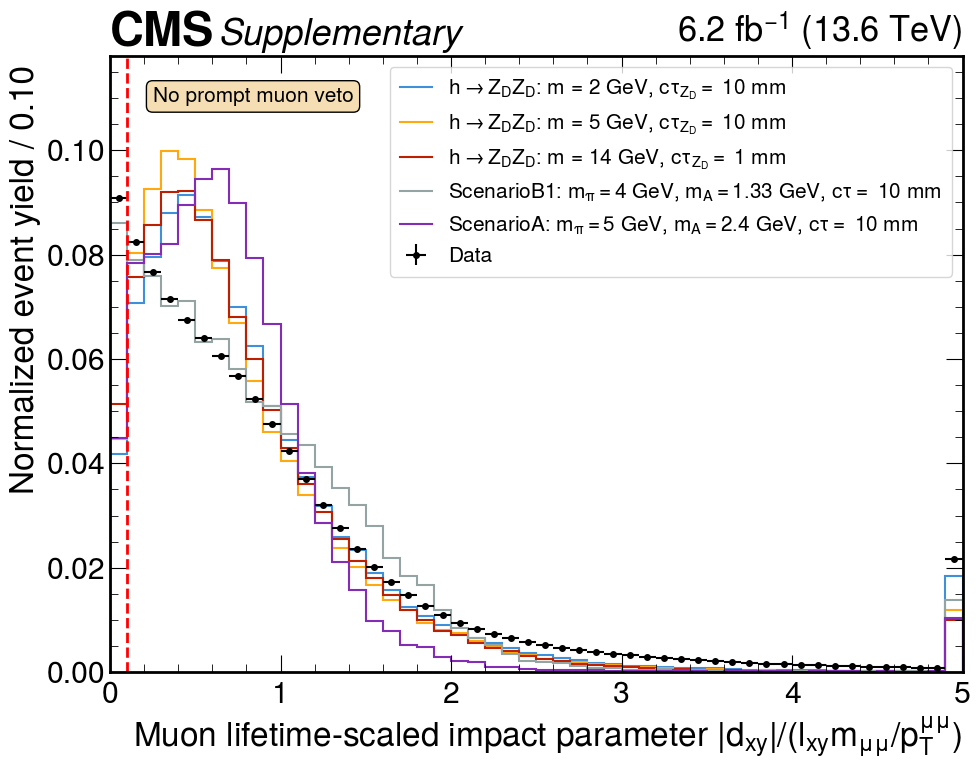

In [8]:
#colors = ["#3f90da", "#ffa90e", "#bd1f01", "#94a4a2", "#832db6", "#a96b59", "#e76300", "#b9ac70", "#717581", "#92dadd"]

period = 'allYears'
#
cephpath = '/ceph/cms/store/user/fernance/Run3ScoutingOutput/outputHistograms_Jun-27-2024_noMuonIPSel_allYears'
#
samples = []
samples.append('Data')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-10mm')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-5p0_ctau-10mm')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1mm')
samples.append('Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-10.00mm')
samples.append('Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm')
#
legnames = {}
legnames['Data'] = r'Data'
legnames['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-10mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 2 GeV, $c\tau_{{Z_{{D}}}} =$ 10 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-5p0_ctau-10mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 5 GeV, $c\tau_{{Z_{{D}}}} =$ 10 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1mm'] = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 14 GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"
legnames['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-10.00mm'] = r"ScenarioB1: $m_\pi = 4$ GeV, $m_A = 1.33$ GeV, $c\tau =$ 10 mm"
legnames['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm'] = r"ScenarioA: $m_\pi = 5$ GeV, $m_A = 2.4$ GeV, $c\tau =$ 10 mm"
#
colors = {}
colors['Data'] = 'k'
colors['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-10mm'] = '#3f90da'
colors['Signal_HTo2ZdTo2mu2x_MZd-5p0_ctau-10mm'] =  '#ffa90e'
colors['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1mm'] =  '#bd1f01'
colors['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-10.00mm'] =  '#94a4a2'
colors['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm'] =  '#832db6'

hist_list = [] # dirpath, hname, lxy range, x-label, y-log, , rebin
hist_list.append([cephpath,
                  'hselmuon_dxysig',
                  r'Muon impact parameter significance $|d_{xy}|/\sigma_{d_{xy}}$',
                  False,
                  2,
                  4,
                  ''])
hist_list.append([cephpath,
                  'hselmuon_dxyscaled',
                  r'Muon lifetime-scaled impact parameter $|d_{xy}|/(l_{xy}m_{\mu\mu}/p_T^{\mu\mu})$',
                  False,
                  0.1,
                  10,
                  ''])

for hist in hist_list:
    plotSupplementaryHistograms(hist, samples, legnames, colors, period, ylog=True, text='No prompt muon veto')

### Number of excess hits

Supplementary material on the number of excess hits

In [ ]:
period = 'allYears'
#
cephpath = '/ceph/cms/store/user/fernance/Run3ScoutingOutput/'
#
samples = []
samples.append('Data')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-10mm')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-5p0_ctau-10mm')
samples.append('Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1mm')
samples.append('Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-10.00mm')
samples.append('Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm')
#
legnames = {}
legnames['Data'] = r'Data'
legnames['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-10mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 2 GeV, $c\tau_{{Z_{{D}}}} =$ 10 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-5p0_ctau-10mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 5 GeV, $c\tau_{{Z_{{D}}}} =$ 10 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1mm'] = r"$h\rightarrow Z_{{D}}Z_{{D}}$: m = 14 GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"
legnames['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-10.00mm'] = r"ScenarioB1: $m_\pi = 4$ GeV, $m_A = 1.33$ GeV, $c\tau =$ 10 mm"
legnames['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm'] = r"ScenarioA: $m_\pi = 5$ GeV, $m_A = 2.4$ GeV, $c\tau =$ 10 mm"
#
colors = {}
colors['Data'] = 'k'
colors['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-10mm'] = '#3f90da'
colors['Signal_HTo2ZdTo2mu2x_MZd-5p0_ctau-10mm'] =  '#ffa90e'
colors['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-1mm'] =  '#bd1f01'
colors['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-10.00mm'] =  '#94a4a2'
colors['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm'] =  '#832db6'

hist_list = [] # dirpath, hname, lxy range, x-label, y-log, , rebin
hist_list.append([cephpath,
                  'hselmuon_dxysig',
                  r'Muon impact parameter significance $|d_{xy}|/\sigma_{d_{xy}}$',
                  False,
                  2,
                  4,
                  ''])
hist_list.append([cephpath,
                  'hselmuon_dxyscaled',
                  r'Muon lifetime-scaled impact parameter $|d_{xy}|/(l_{xy}m_{\mu\mu}/p_T^{\mu\mu})$',
                  False,
                  0.1,
                  10,
                  ''])

for hist in hist_list:
    plotSupplementaryHistograms(hist, samples, legnames, colors, period, ylog=True, text='No prompt muon veto')